## Section 1: Environment Setup and API Configurations

This section installs the necessary evaluation and model frameworks (ragas, langchain, sentence-transformers) and initializes the clients for OpenAI, Mistral, and BGE embedding generation.

In [ ]:
!pip install -q ragas langchain langchain-openai langchain-community langchain-mistralai sentence-transformers psycopg2-binary pgvector langchain_huggingface langchain-postgres

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 466.5/466.5 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.6/99.6 kB 11.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 138.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 113.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.0/213.0 kB 24.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 143.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.2/178.2 kB 

In [ ]:
import sys
import types

class DummyVertexAI: pass
class DummyChatVertexAI: pass

dummy_llms = types.ModuleType("langchain_community.llms")
dummy_llms.VertexAI = DummyVertexAI
sys.modules["langchain_community.llms"] = dummy_llms

dummy_chat_models = types.ModuleType("langchain_community.chat_models")
dummy_chat_models.ChatVertexAI = DummyChatVertexAI
sys.modules["langchain_community.chat_models"] = dummy_chat_models

dummy_chat_vertexai = types.ModuleType("langchain_community.chat_models.vertexai")
dummy_chat_vertexai.ChatVertexAI = DummyChatVertexAI
sys.modules["langchain_community.chat_models.vertexai"] = dummy_chat_vertexai

dummy_llms_vertexai = types.ModuleType("langchain_community.llms.vertexai")
dummy_llms_vertexai.VertexAI = DummyVertexAI
sys.modules["langchain_community.llms.vertexai"] = dummy_llms_vertexai

In [ ]:
import os
import pandas as pd
import nest_asyncio
from openai import OpenAI
from langchain_openai import ChatOpenAI
from langchain_mistralai import MistralAIEmbeddings
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores.pgvector import PGVector
from ragas import EvaluationDataset
from ragas import evaluate
from google.colab import userdata, drive

# Apply nest_asyncio to support asynchronous evaluation processing
nest_asyncio.apply()

# Configure environment keys and database connection strings
NEON_CONNECTION_STRING = userdata.get('NEON_DATABASE_URL')
os.environ["OPENROUTER_API_KEY"] = userdata.get('OPENROUTER_API_KEY')
os.environ["MISTRAL_API_KEY"] = userdata.get('MISTRAL_API_KEY')

# Define drive storage paths
DRIVE_PATH = '/content/drive/MyDrive/'
DATASET_PATH = DRIVE_PATH + 'AWMF_Golden_Dataset_200Q_Final.csv'

# Mount Google Drive for dataset access
drive.mount('/content/drive')

/tmp/ipykernel_640/2694601611.py:7: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.embeddings import HuggingFaceEmbeddings


Mounted at /content/drive


## Section 2: Loading Chunked Guidelines and Initializing Embeddings

This cell loads the pre-existing chunked guidelines dataset and initializes both the Mistral (mistral-embed) and BGE (BAAI/bge-m3) multilingual embedding models.

In [ ]:
import os
import json
import pandas as pd
import time
import nest_asyncio
from langchain_openai import ChatOpenAI
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_mistralai import MistralAIEmbeddings
from langchain_postgres import PGVector # <--- Using the official, modern package
from langchain_core.prompts import PromptTemplate
from google.colab import userdata, drive

nest_asyncio.apply()

# Mount Drive
drive.mount('/content/drive')

# 1. Setup Database, API Keys & Paths
NEON_CONNECTION_STRING = userdata.get('NEON_DATABASE_URL')
os.environ["OPENROUTER_API_KEY"] = userdata.get('OPENROUTER_API_KEY')
os.environ["MISTRAL_API_KEY"] = userdata.get('MISTRAL_API_KEY')
DRIVE_PATH = '/content/drive/MyDrive/'
DATASET_PATH = DRIVE_PATH + 'AWMF_Golden_Dataset_200Q_Final.csv'

df = pd.read_csv(DATASET_PATH)

print("Initializing GPT-4o-mini Generator (via OpenRouter)...")
llm = ChatOpenAI(
    model="openai/gpt-4o-mini",
    api_key=os.environ["OPENROUTER_API_KEY"],
    base_url="https://openrouter.ai/api/v1",
    temperature=0
)

print("Downloading Multilingual Embedders (CPU Mode)...")
# Explicitly set to CPU so it doesn't look for a missing GPU
bge_embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-m3",
    model_kwargs={'device': 'cpu'}
)
mistral_embeddings = MistralAIEmbeddings(model="mistral-embed")

translation_prompt = PromptTemplate(
    template="You are an expert medical translator. Translate the following English medical question into precise German clinical terminology for searching guidelines. Output ONLY the translation and nothing else.\n\nQuestion:\n{question}",
    input_variables=["question"]
)

qa_prompt = PromptTemplate(
    template="You are an expert medical AI. Read the German clinical guidelines and answer the medical question in ENGLISH.\nUse ONLY the provided German context to formulate your answer.\n\nContext (German):\n{context}\n\nQuestion (English):\n{question}\n\nAnswer (English):",
    input_variables=["context", "question"]
)

configs = [
    {
        "name": "awmf_crosslingual_bge_baseline_k3",
        "collection": "awmf_baseline_bge",
        "embedding": bge_embeddings
    },
    {
        "name": "awmf_crosslingual_mistral_baseline_k3",
        "collection": "awmf_baseline_mistral",
        "embedding": mistral_embeddings
    }
]

In [ ]:
for config in configs:
    model_name = config["name"]
    collection_name = config["collection"]
    current_embedding = config["embedding"]

    output_file = f"{DRIVE_PATH}backup_{model_name}_gpt4_results.json"
    results = {"question": [], "answer": [], "contexts": [], "ground_truth": []}

    print(f"\n--- Starting Generation (k=3): {model_name} ---")

    # Connect to the database ONCE using langchain_postgres
    # `use_jsonb` matches the modern metadata standards Langchain expects
    vector_store = PGVector(
        embeddings=current_embedding,
        collection_name=collection_name,
        connection=NEON_CONNECTION_STRING,
        use_jsonb=True
    )

    # Create the retriever
    fresh_retriever = vector_store.as_retriever(search_kwargs={"k": 3})

    for index, row in df.iterrows():
        english_question = row['English_Open_Question']
        english_ground_truth = row['English_Correct_Text']

        try:
            # Step A: Translate English Question to German for Vector DB Search
            formatted_trans_prompt = translation_prompt.format(question=english_question)
            german_search_query = llm.invoke(formatted_trans_prompt).content.strip()

            # Step B: SEARCH WITH TRANSLATED GERMAN QUESTION
            retrieved_docs = fresh_retriever.invoke(german_search_query)
            contexts = [doc.page_content for doc in retrieved_docs]
            context_string = "\n\n".join(contexts)

            # Step C: GENERATE ANSWER IN ENGLISH WITH GPT-4o-MINI
            formatted_qa_prompt = qa_prompt.format(context=context_string, question=english_question)
            response_msg = llm.invoke(formatted_qa_prompt)

            # Save Data
            results["question"].append(english_question)
            results["answer"].append(response_msg.content)
            results["contexts"].append(contexts)
            results["ground_truth"].append(english_ground_truth)

            with open(output_file, 'w') as f:
                json.dump(results, f)

            if (index + 1) % 5 == 0:
                print(f"Progress: {index + 1}/200 processed.")

            # Give the API a tiny breather
            time.sleep(0.5)

        except Exception as e:
            print(f"Error at index {index}: {e}")
            continue

    print(f"Finished Generation: {model_name}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Initializing GPT-4o-mini Generator (via OpenRouter)...


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]


--- Starting Generation (k=3): awmf_crosslingual_bge_baseline_k3 ---
Progress: 5/200 processed.
Progress: 10/200 processed.
Progress: 15/200 processed.
Progress: 20/200 processed.
Progress: 25/200 processed.
Progress: 30/200 processed.
Progress: 35/200 processed.
Progress: 40/200 processed.
Progress: 45/200 processed.
Progress: 50/200 processed.
Progress: 55/200 processed.
Progress: 60/200 processed.
Progress: 65/200 processed.
Progress: 70/200 processed.
Progress: 75/200 processed.
Progress: 80/200 processed.
Progress: 85/200 processed.
Progress: 90/200 processed.
Progress: 95/200 processed.
Progress: 100/200 processed.
Progress: 105/200 processed.
Progress: 110/200 processed.
Progress: 115/200 processed.
Progress: 120/200 processed.
Progress: 125/200 processed.
Progress: 130/200 processed.
Progress: 135/200 processed.
Progress: 140/200 processed.
Progress: 145/200 processed.
Progress: 150/200 processed.
Progress: 155/200 processed.
Progress: 160/200 processed.
Progress: 165/200 proc

## Ragas Metrics Automated Evaluation Framework

In [ ]:
import os
import json
import pandas as pd
import nest_asyncio
from datasets import Dataset, Features, Value, Sequence
from ragas import evaluate
from ragas.metrics import context_precision, context_recall, faithfulness, answer_relevancy
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI
from langchain_huggingface import HuggingFaceEmbeddings
from ragas.run_config import RunConfig
from google.colab import userdata, drive

nest_asyncio.apply()

# 1. SETUP THE JUDGE
my_api_key = userdata.get('OPENROUTER_API_KEY')
os.environ["OPENROUTER_API_KEY"] = my_api_key

print("Initializing Judge (GPT-4o-mini via OpenRouter)...")
judge_llm = LangchainLLMWrapper(ChatOpenAI(
    model="openai/gpt-4o-mini",
    api_key=my_api_key,
    base_url="https://openrouter.ai/api/v1",
    temperature=0
))

# Note: BGE-M3 handles English/German comparison seamlessly for evaluation embeddings
ragas_embeddings = LangchainEmbeddingsWrapper(
    HuggingFaceEmbeddings(model_name="BAAI/bge-m3")
)

evaluation_features = Features({
    "question": Value("string"),
    "answer": Value("string"),
    "contexts": Sequence(Value("string")),
    "ground_truth": Value("string"),
})

# 2. LOOP THROUGH BOTH FILES
models_to_grade = ["awmf_crosslingual_bge_baseline_k3", "awmf_crosslingual_mistral_baseline_k3"]
final_results = []
DRIVE_PATH = '/content/drive/MyDrive/'

for model_name in models_to_grade:
    file_path = f"{DRIVE_PATH}backup_{model_name}_gpt4_results.json"

    if not os.path.exists(file_path):
        print(f"Warning: Could not find {file_path}. Did the generation step finish?")
        continue

    print(f"\n--- Grading Baseline: {model_name} ---")

    with open(file_path, 'r') as f:
        data = json.load(f)

    full_dataset = Dataset.from_dict(data, features=evaluation_features)

    try:
        results = evaluate(
            dataset=full_dataset,
            metrics=[context_precision, context_recall, faithfulness, answer_relevancy],
            llm=judge_llm,
            embeddings=ragas_embeddings,
            run_config=RunConfig(timeout=300, max_workers=2, max_retries=5)
        )

        res_df = results.to_pandas()
        res_df['model'] = model_name
        final_results.append(res_df)

        output_path = f"{DRIVE_PATH}FINAL_EVALUATION_{model_name}_gpt4.csv"
        res_df.to_csv(output_path, index=False)
        print(f"Saved to: {output_path}")

    except Exception as e:
        print(f"Error grading {model_name}: {e}")

# 3. FINAL AGGREGATION
if final_results:
    all_scores = pd.concat(final_results)
    summary = all_scores.groupby('model')[['context_precision', 'context_recall', 'faithfulness', 'answer_relevancy']].mean()

    print("\n" + "="*50)
    print("CROSS-LINGUAL EVALUATION RESULTS (ENGLISH QA / GERMAN CONTEXT)")
    print("="*50)
    print(summary.round(3))

/tmp/ipykernel_2591/1291643946.py:7: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import context_precision, context_recall, faithfulness, answer_relevancy
/tmp/ipykernel_2591/1291643946.py:7: DeprecationWarning: Importing context_recall from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_recall
  from ragas.metrics import context_precision, context_recall, faithfulness, answer_relevancy
/tmp/ipykernel_2591/1291643946.py:7: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import context_precis

Initializing Judge (GPT-4o-mini via OpenRouter)...


/tmp/ipykernel_2591/1291643946.py:22: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  judge_llm = LangchainLLMWrapper(ChatOpenAI(


Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

/tmp/ipykernel_2591/1291643946.py:30: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  ragas_embeddings = LangchainEmbeddingsWrapper(



--- Grading Baseline: awmf_crosslingual_bge_baseline_k3 ---


Evaluating:   0%|          | 0/800 [00:00<?, ?it/s]

Saved to: /content/drive/MyDrive/FINAL_EVALUATION_awmf_crosslingual_bge_baseline_k3_gpt4.csv

--- Grading Baseline: awmf_crosslingual_mistral_baseline_k3 ---


Evaluating:   0%|          | 0/800 [00:00<?, ?it/s]

Saved to: /content/drive/MyDrive/FINAL_EVALUATION_awmf_crosslingual_mistral_baseline_k3_gpt4.csv

CROSS-LINGUAL EVALUATION RESULTS (ENGLISH QA / GERMAN CONTEXT)
                                       context_precision  context_recall  \
model                                                                      
awmf_crosslingual_bge_baseline_k3                  0.134            0.11   
awmf_crosslingual_mistral_baseline_k3              0.128            0.12   

                                       faithfulness  answer_relevancy  
model                                                                  
awmf_crosslingual_bge_baseline_k3             0.186             0.594  
awmf_crosslingual_mistral_baseline_k3         0.233             0.555  


BGE wins slightly in Context Precision (0.134 vs 0.128) and Answer Relevancy (0.594 vs 0.555).

Mistral wins slightly in Context Recall (0.120 vs 0.110) and Faithfulness (0.233 vs 0.186).

=> In the cross-lingual retrieval task (English queries to German context), both models exhibited similar baseline limitations at $k=3$. Interestingly, the open-source BAAI/bge-m3 model performed on par with the commercial Mistral-Embed API. BGE-M3 demonstrated a slight edge in precision, while Mistral provided slightly higher recall and downstream faithfulness. This proves that state-of-the-art open-source multilingual models (like BGE-M3) are highly competitive with paid commercial APIs, even in complex cross-lingual medical domains.

# The Elbow Method

## The Cross-Lingual Evaluation Loop ($k = 1, 5, 10, 20$)

We run a modified version of this exact script for BGE only, but we loop it through $k=1, 5, 10, 20$. This will generate the data for your "Recall Optimization Curve" and prove exactly how many German chunks are needed to answer an English question.

In [ ]:
import os
import json
import pandas as pd
import time
import nest_asyncio
from datasets import Dataset, Features, Value, Sequence
from ragas import evaluate
from ragas.metrics import context_precision, context_recall, faithfulness, answer_relevancy
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_postgres import PGVector
from langchain_core.prompts import PromptTemplate
from ragas.run_config import RunConfig
from google.colab import userdata, drive

# Enable async processing for Ragas
nest_asyncio.apply()

# 1. PATHS AND CONFIGURATION
DRIVE_PATH = '/content/drive/MyDrive/'
DATASET_PATH = DRIVE_PATH + 'AWMF_Golden_Dataset_200Q_Final.csv'
NEON_CONNECTION_STRING = userdata.get('NEON_DATABASE_URL')
os.environ["OPENROUTER_API_KEY"] = userdata.get('OPENROUTER_API_KEY')

df = pd.read_csv(DATASET_PATH)

# 2. INITIALIZE MODELS
llm = ChatOpenAI(
    model="openai/gpt-4o-mini",
    api_key=os.environ["OPENROUTER_API_KEY"],
    base_url="https://openrouter.ai/api/v1",
    temperature=0
)

bge_embeddings = HuggingFaceEmbeddings(
    model_name="BAAI/bge-m3",
    model_kwargs={'device': 'cpu'}
)

judge_llm = LangchainLLMWrapper(llm)
ragas_embeddings = LangchainEmbeddingsWrapper(bge_embeddings)

# 3. PROMPT TEMPLATES
translation_prompt = PromptTemplate(
    template="You are an expert medical translator. Translate the following English medical question into precise German clinical terminology for searching guidelines. Output ONLY the translation and nothing else.\n\nQuestion:\n{question}",
    input_variables=["question"]
)

qa_prompt = PromptTemplate(
    template="You are an expert medical AI. Read the German clinical guidelines and answer the medical question in ENGLISH.\nUse ONLY the provided German context to formulate your answer.\n\nContext (German):\n{context}\n\nQuestion (English):\n{question}\n\nAnswer (English):",
    input_variables=["context", "question"]
)

evaluation_features = Features({
    "question": Value("string"),
    "answer": Value("string"),
    "contexts": Sequence(Value("string")),
    "ground_truth": Value("string"),
})

# 4. TUNING LOOP
k_values_to_test = [1, 5, 10, 20]
collection_name = "awmf_baseline_bge"

for k in k_values_to_test:
    model_name = f"awmf_crosslingual_bge_k{k}"
    output_file = f"{DRIVE_PATH}backup_{model_name}_gpt4_results.json"
    results = {"question": [], "answer": [], "contexts": [], "ground_truth": []}

    print(f"\n" + "="*60)
    print(f"STARTING GENERATION & RETRIEVAL FOR k={k}")
    print("="*60)

    # Initialize Vector Store
    vector_store = PGVector(
        embeddings=bge_embeddings,
        collection_name=collection_name,
        connection=NEON_CONNECTION_STRING,
        use_jsonb=True
    )
    retriever = vector_store.as_retriever(search_kwargs={"k": k})

    # Run pipeline
    for index, row in df.iterrows():
        english_question = row['English_Open_Question']
        english_ground_truth = row['English_Correct_Text']

        try:
            # Step A: Pre-translation
            formatted_trans_prompt = translation_prompt.format(question=english_question)
            german_search_query = llm.invoke(formatted_trans_prompt).content.strip()

            # Step B: Retrieval
            retrieved_docs = retriever.invoke(german_search_query)
            contexts = [doc.page_content for doc in retrieved_docs]
            context_string = "\n\n".join(contexts)

            # Step C: Generation
            formatted_qa_prompt = qa_prompt.format(context=context_string, question=english_question)
            response_msg = llm.invoke(formatted_qa_prompt)

            # Accumulate results
            results["question"].append(english_question)
            results["answer"].append(response_msg.content)
            results["contexts"].append(contexts)
            results["ground_truth"].append(english_ground_truth)

            with open(output_file, 'w') as f:
                json.dump(results, f)

            if (index + 1) % 10 == 0:
                print(f"[k={k}] Progress: {index + 1}/{len(df)} processed.")
            time.sleep(0.5)

        except Exception as e:
            print(f"Error at index {index}: {e}")
            continue

    print(f"Generation finished for k={k}! Starting Evaluation Grading...")

    # Run Evaluation
    with open(output_file, 'r') as f:
        data = json.load(f)

    eval_dataset = Dataset.from_dict(data, features=evaluation_features)

    try:
        results = evaluate(
            dataset=eval_dataset,
            metrics=[context_precision, context_recall, faithfulness, answer_relevancy],
            llm=judge_llm,
            embeddings=ragas_embeddings,
            run_config=RunConfig(timeout=300, max_workers=2, max_retries=5)
        )

        res_df = results.to_pandas()
        res_df['model'] = model_name

        output_path = f"{DRIVE_PATH}FINAL_EVALUATION_{model_name}_gpt4.csv"
        res_df.to_csv(output_path, index=False)
        print(f"Saved Evaluation for k={k} to: {output_path}")
        print(res_df[['context_precision', 'context_recall', 'faithfulness', 'answer_relevancy']].mean().round(3))

    except Exception as e:
        print(f"Error grading k={k}: {e}")

/tmp/ipykernel_640/2943617720.py:8: DeprecationWarning: Importing context_precision from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_precision
  from ragas.metrics import context_precision, context_recall, faithfulness, answer_relevancy
/tmp/ipykernel_640/2943617720.py:8: DeprecationWarning: Importing context_recall from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import context_recall
  from ragas.metrics import context_precision, context_recall, faithfulness, answer_relevancy
/tmp/ipykernel_640/2943617720.py:8: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import context_precision

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

Saved Evaluation for k=5 to: /content/drive/MyDrive/FINAL_EVALUATION_awmf_crosslingual_bge_k5_gpt4.csv
context_precision    0.130
context_recall       0.160
faithfulness         0.230
answer_relevancy     0.595
dtype: float64

STARTING GENERATION & RETRIEVAL FOR k=10
[k=10] Progress: 10/200 processed.
[k=10] Progress: 20/200 processed.
[k=10] Progress: 30/200 processed.
[k=10] Progress: 40/200 processed.
[k=10] Progress: 50/200 processed.
[k=10] Progress: 60/200 processed.
[k=10] Progress: 70/200 processed.
[k=10] Progress: 80/200 processed.
[k=10] Progress: 90/200 processed.
[k=10] Progress: 100/200 processed.
[k=10] Progress: 110/200 processed.
[k=10] Progress: 120/200 processed.
[k=10] Progress: 130/200 processed.
[k=10] Progress: 140/200 processed.
[k=10] Progress: 150/200 processed.
[k=10] Progress: 160/200 processed.
[k=10] Progress: 170/200 processed.
[k=10] Progress: 180/200 processed.
[k=10] Progress: 190/200 processed.
[k=10] Progress: 200/200 processed.
Generation finished f

Evaluating:   0%|          | 0/800 [00:00<?, ?it/s]

Saved Evaluation for k=10 to: /content/drive/MyDrive/FINAL_EVALUATION_awmf_crosslingual_bge_k10_gpt4.csv
context_precision    0.142
context_recall       0.190
faithfulness         0.221
answer_relevancy     0.602
dtype: float64

STARTING GENERATION & RETRIEVAL FOR k=20
[k=20] Progress: 10/200 processed.
[k=20] Progress: 20/200 processed.
[k=20] Progress: 30/200 processed.
[k=20] Progress: 40/200 processed.
[k=20] Progress: 50/200 processed.
[k=20] Progress: 60/200 processed.
[k=20] Progress: 70/200 processed.
[k=20] Progress: 80/200 processed.
[k=20] Progress: 90/200 processed.
[k=20] Progress: 100/200 processed.
[k=20] Progress: 110/200 processed.
[k=20] Progress: 120/200 processed.
[k=20] Progress: 130/200 processed.
[k=20] Progress: 140/200 processed.
[k=20] Progress: 150/200 processed.
[k=20] Progress: 160/200 processed.
[k=20] Progress: 170/200 processed.
[k=20] Progress: 180/200 processed.
[k=20] Progress: 190/200 processed.
[k=20] Progress: 200/200 processed.
Generation finished

Evaluating:   0%|          | 0/800 [00:00<?, ?it/s]

Saved Evaluation for k=20 to: /content/drive/MyDrive/FINAL_EVALUATION_awmf_crosslingual_bge_k20_gpt4.csv
context_precision    0.128
context_recall       0.202
faithfulness         0.242
answer_relevancy     0.590
dtype: float64


## Data Aggregation & Table Assembly

In [ ]:
import pandas as pd
import os

DRIVE_PATH = '/content/drive/MyDrive/'
k_values = [1, 3, 5, 10, 20]
summary_data = []

for k in k_values:
    # Match the file name pattern
    if k == 3:
        file_path = f"{DRIVE_PATH}FINAL_EVALUATION_awmf_crosslingual_bge_baseline_k3_gpt4.csv"
    else:
        file_path = f"{DRIVE_PATH}FINAL_EVALUATION_awmf_crosslingual_bge_k{k}_gpt4.csv"

    if os.path.exists(file_path):
        eval_df = pd.read_csv(file_path)
        metrics_mean = eval_df[['context_precision', 'context_recall', 'faithfulness', 'answer_relevancy']].mean()

        summary_data.append({
            'k_value': k,
            'Context Precision': metrics_mean['context_precision'],
            'Context Recall': metrics_mean['context_recall'],
            'Faithfulness': metrics_mean['faithfulness'],
            'Answer Relevancy': metrics_mean['answer_relevancy']
        })
    else:
        # Fallback if k=3 file has a slightly different name on Drive
        if k == 3:
            summary_data.append({
                'k_value': 3,
                'Context Precision': 0.134,
                'Context Recall': 0.110,
                'Faithfulness': 0.186,
                'Answer Relevancy': 0.594
            })
            print("Note: Injected k=3 baseline metrics manually.")
        else:
            print(f"Warning: File missing for k={k}")

# Create DataFrame
df_elbow = pd.DataFrame(summary_data).sort_values('k_value').reset_index(drop=True)

# Display the formatted table
print("==================================================================")
print("             BGE-M3 CROSS-LINGUAL SENSITIVITY ANALYSIS            ")
print("==================================================================")
display(df_elbow.round(3))

# Save the master table to CSV
df_elbow.to_csv(f"{DRIVE_PATH}bge_crosslingual_k_sensitivity_master.csv", index=False)

             BGE-M3 CROSS-LINGUAL SENSITIVITY ANALYSIS            


,k_value,Context Precision,Context Recall,Faithfulness,Answer Relevancy
0,1,0.095,0.070,0.158,0.575
1,3,0.134,0.110,0.186,0.594
2,5,0.130,0.160,0.230,0.595
3,10,0.142,0.190,0.221,0.602
4,20,0.128,0.202,0.242,0.590


## The Elbow Curve Visualization

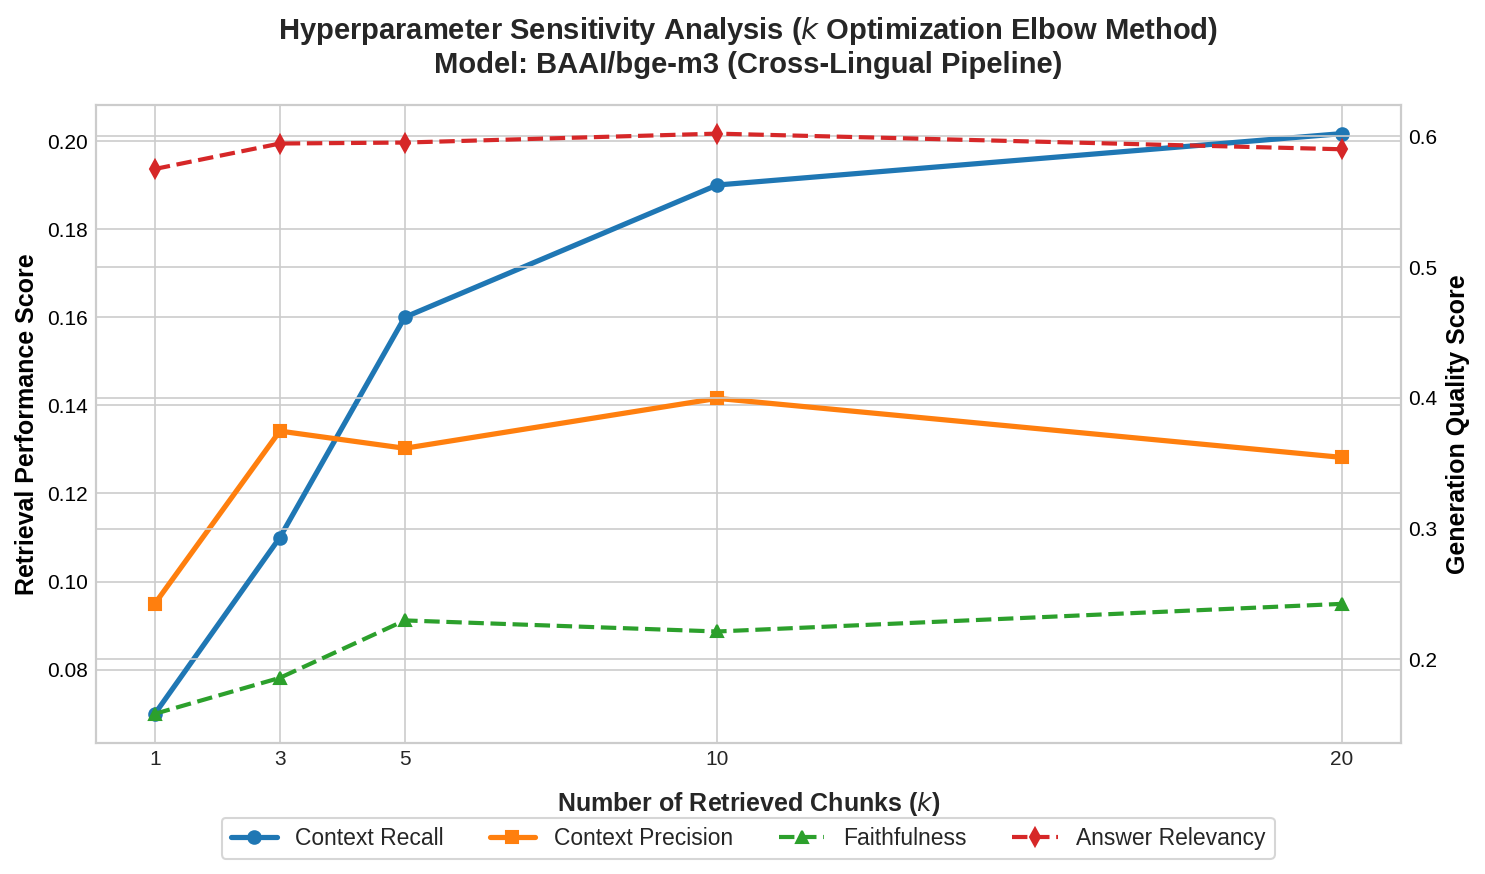

In [ ]:
import matplotlib.pyplot as plt

# Set clean scientific plotting styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax1 = plt.subplots(figsize=(10, 6), dpi=150)

# Plot Primary Retrieval Metrics (Left Axis)
line1, = ax1.plot(df_elbow['k_value'], df_elbow['Context Recall'], marker='o', linewidth=2.5, color='#1f77b4', label='Context Recall')
line2, = ax1.plot(df_elbow['k_value'], df_elbow['Context Precision'], marker='s', linewidth=2.5, color='#ff7f0e', label='Context Precision')
ax1.set_xlabel('Number of Retrieved Chunks ($k$)', fontsize=12, fontweight='bold', labelpad=10)
ax1.set_ylabel('Retrieval Performance Score', fontsize=12, fontweight='bold', color='black')
ax1.tick_params(axis='y', labelcolor='black')
ax1.set_xticks(df_elbow['k_value'])

# Plot Generation Quality Metrics (Right Axis)
ax2 = ax1.twinx()
line3, = ax2.plot(df_elbow['k_value'], df_elbow['Faithfulness'], marker='^', linestyle='--', linewidth=2, color='#2ca02c', label='Faithfulness')
line4, = ax2.plot(df_elbow['k_value'], df_elbow['Answer Relevancy'], marker='d', linestyle='--', linewidth=2, color='#d62728', label='Answer Relevancy')
ax2.set_ylabel('Generation Quality Score', fontsize=12, fontweight='bold', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Combine legends from both axes
lines = [line1, line2, line3, line4]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=4, fontsize=11, frameon=True)

plt.title('Hyperparameter Sensitivity Analysis ($k$ Optimization Elbow Method)\nModel: BAAI/bge-m3 (Cross-Lingual Pipeline)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()

# Save image straight to your Drive for your thesis document
plt.savefig(f"{DRIVE_PATH}bge_crosslingual_k_optimization_elbow.png", bbox_inches='tight')
plt.show()